# PV056 — Topic 1: Human Activity Recognition

Dataset: UCI HAR (smartphone inertial sensors)  
Goal: classify 6 activities; beat LSTM baseline (F1-macro > 0.80)

**General (every topic):**

- R1a — visualize class label distribution
- R1b — find/visualize outliers or anomalies
- R2a — use HPO (hyperparameter optimization) to find hyperparameters
- R2b — visualize training progress, train to convergence
- R3a — explore successful/failed cases (confusion matrix, explainability)
- R3b — present results in a suitable form

**Topic 1 specific:**
- T1a — data analysis to uncover tough cases (e.g. T-SNE, error analysis, sequence patterns like "does sitting→climbing stairs co-occur?")
- T1b — improve over the given LSTM baseline (~0.80 F1-macro)

## 1. Setup & Data Loading

In [47]:
# !pip install -r requirements.txt

In [48]:
%reset

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
import sklearn as sk
import torch
import optuna


In [50]:
df_train = pd.read_csv("./data/train.csv")
df_test = pd.read_csv("./data/test.csv")

print(df_train.shape, df_test.shape)

(7352, 563) (2947, 563)


In [51]:
df_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [52]:
df_test.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING


## 2. [R1a] Class Label Distribution

In [53]:
df_train['Activity'].value_counts()

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

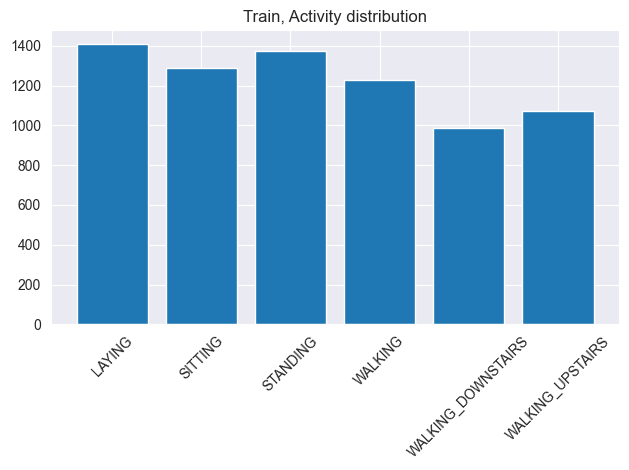

In [54]:
counts = df_train['Activity'].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.title('Train, Activity distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [55]:
df_test['Activity'].value_counts()

Activity
LAYING                537
STANDING              532
WALKING               496
SITTING               491
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
Name: count, dtype: int64

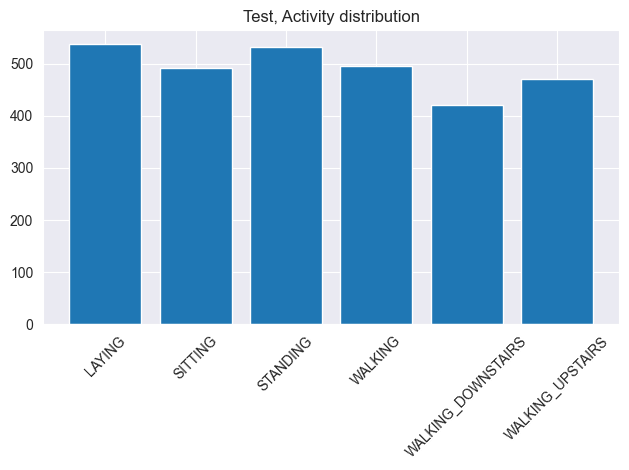

In [56]:
counts = df_test['Activity'].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.title('Test, Activity distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [57]:
df_train['subject'].value_counts()

subject
25    409
21    408
26    392
30    383
28    382
27    376
23    372
17    368
16    366
19    360
1     347
29    344
3     341
15    328
6     325
14    323
22    321
11    316
7     308
5     302
8     281
Name: count, dtype: int64

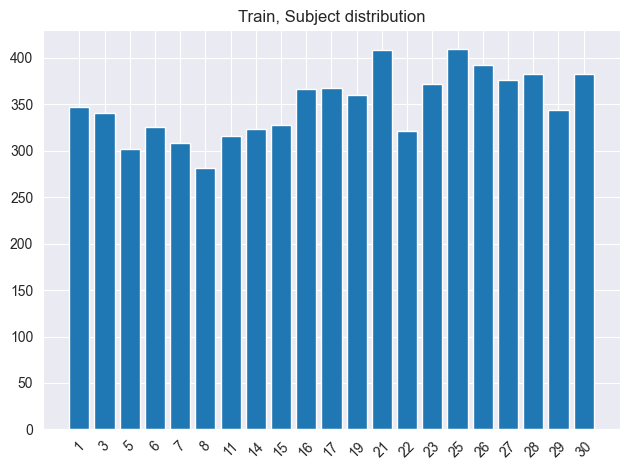

In [58]:
counts = df_train['subject'].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title('Train, Subject distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Some subjects are missing in train.

Missing: 2, 4, 9, 10, 12, 13, 18, 20, 24

In [59]:
df_test['subject'].value_counts()

subject
24    381
18    364
20    354
13    327
12    320
4     317
2     302
10    294
9     288
Name: count, dtype: int64

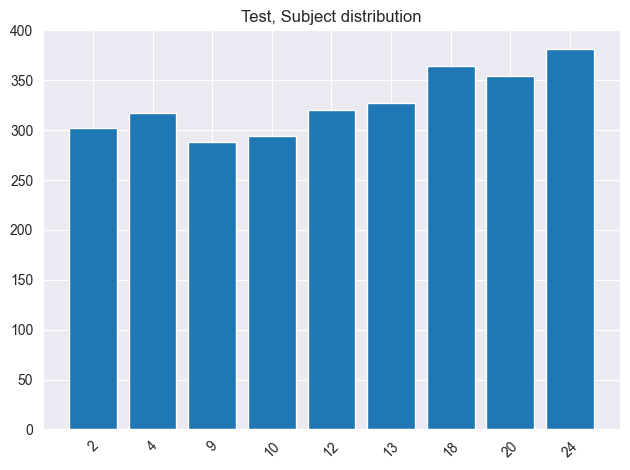

In [60]:
counts = df_test['subject'].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title('Test, Subject distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Missing subjects are found in test!

### **Notice that subjects in train and test are not the same!**

Test complements the train, be aware of that.

# Build baseline first

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

LABEL_COL = 'Activity'
DROP_COLS = ['Activity', 'subject']

X_train = df_train.drop(columns=DROP_COLS).values
y_train = df_train[LABEL_COL].values
X_test  = df_test.drop(columns=DROP_COLS).values
y_test  = df_test[LABEL_COL].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


In [62]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train)
print(f'LR   F1-macro: {f1_score(y_test, lr.predict(X_test_s), average="macro"):.4f}')

# Random Forest (tree-based, no scaling needed)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f'RF   F1-macro: {f1_score(y_test, rf.predict(X_test), average="macro"):.4f}')

print('Baseline target: 0.80')


LR   F1-macro: 0.9547
RF   F1-macro: 0.9234
Baseline target: 0.80


In [63]:
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, lr.predict(X_test_s)))

print("=== Random Forest ===")
print(classification_report(y_test, rf.predict(X_test)))


=== Logistic Regression ===
                    precision    recall  f1-score   support

            LAYING       1.00      0.99      0.99       537
           SITTING       0.97      0.88      0.92       491
          STANDING       0.89      0.97      0.93       532
           WALKING       0.94      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.94      0.96       420
  WALKING_UPSTAIRS       0.96      0.95      0.95       471

          accuracy                           0.95      2947
         macro avg       0.96      0.95      0.95      2947
      weighted avg       0.96      0.95      0.95      2947

=== Random Forest ===
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.89      0.90       491
          STANDING       0.90      0.92      0.91       532
           WALKING       0.88      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.86      0

Results are quite surprising. Classical feature engineering + simple classifier outperforms a naive deep learning baseline. Im continuing with performing required steps and would try to improve the baseline

## 3. [R1b] Outlier / Anomaly Detection

Implementing PCA

In [66]:
from sklearn.decomposition import PCA

N_COMPONENTS = 50

pca = PCA(n_components=N_COMPONENTS)
X_train_pca = pca.fit_transform(X_train_s)
X_train_reconstructed = pca.inverse_transform(X_train_pca)

reconstruction_errors = np.mean((X_train_s - X_train_reconstructed) ** 2, axis=1)


In [67]:
threshold = np.percentile(reconstruction_errors, 95)
outlier_mask = reconstruction_errors > threshold

print(f'Outliers detected: {outlier_mask.sum()} ({outlier_mask.mean()*100:.1f}%)')


Outliers detected: 368 (5.0%)


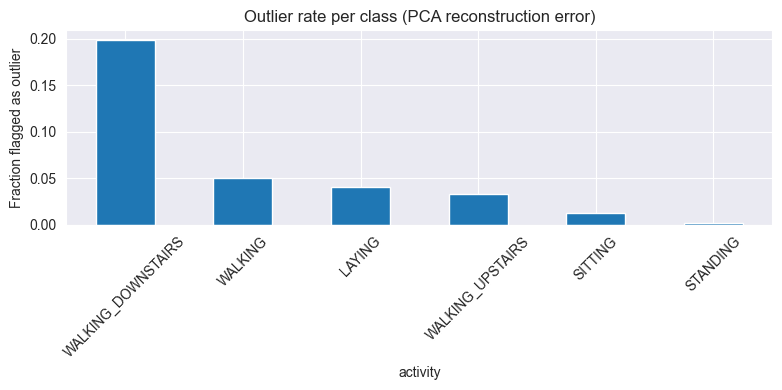

In [68]:
outlier_df = pd.DataFrame({
    'activity': y_train,
    'error': reconstruction_errors,
    'is_outlier': outlier_mask
})

outlier_rate = outlier_df.groupby('activity')['is_outlier'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
outlier_rate.plot(kind='bar')
plt.title('Outlier rate per class (PCA reconstruction error)')
plt.ylabel('Fraction flagged as outlier')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Results look logically. Standing data is quite the same in time, while walking downstairs makes hand move up and down intensively. We come back to it at the end.

## 4. [T1a] Tough Case Analysis

Be aware of differences between subject behaviours within the same class. Visualise per-subject variation within a class.

In [69]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
X_2d = tsne.fit_transform(X_train_s)

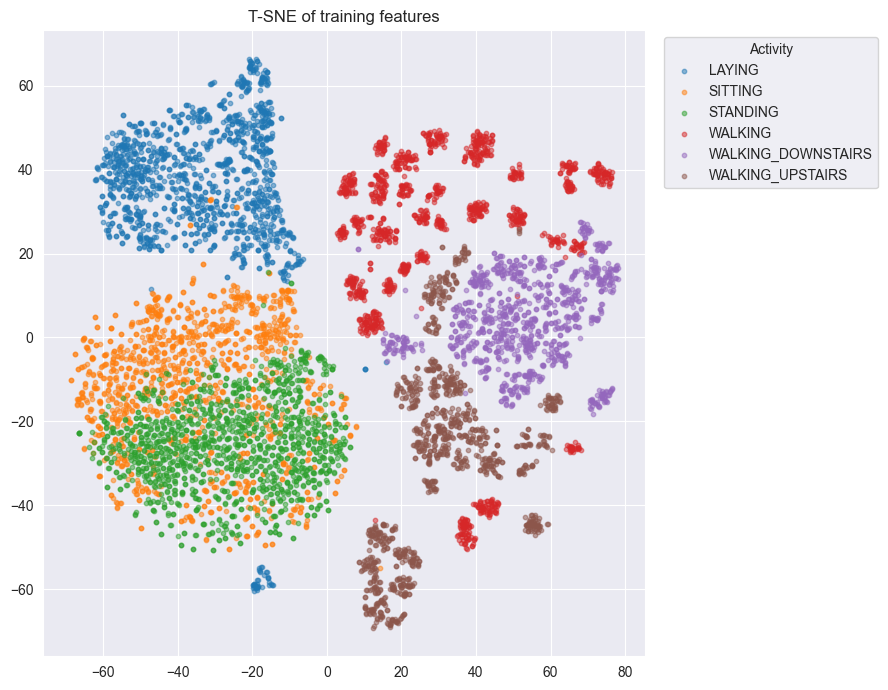

In [70]:
plt.figure(figsize=(9, 7))
for activity in np.unique(y_train):
    mask = y_train == activity
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=activity, alpha=0.5, s=10)
plt.legend(title='Activity', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('T-SNE of training features')
plt.tight_layout()
plt.show()


walking  downstairs has a dense cluster, sitting and standing are quite mixxed up, sounds logically. Laying has its dense cluster as well. Walking has many small clusters, which may sign how people walk differently.

Interesting that T-SNE reveals two distinct regions: static activities (sitting, standing) form an overlapping cluster, while dynamic activities (waling variants) form separate but neighbouring sub-clusters. This explains the lower F1 scores for sitting and standing.

## 5. [R2a/R2b/T1b] Models, HPO, Training

When test different models, be aware of they might require different dataset preparation.
For example XGBoost (doesn't care about scaling (splits are based on rank/thresholds, not distances) vs Neural Networks (care a lot, unscaled features with very different ranges will make training unstable)

**Does the order of windows matter, and how do different models handle (or ignore) that sequence?**
That's the core difference between throwing XGBoost at it vs using an LSTM.

Let's try to implement and evaluate 4 models: XGBoost, SVM, LSTM and Transformer

### 1. XGBoost

In [71]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


In [87]:
from sklearn.model_selection import cross_val_score

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'tree_method': 'hist',
        'eval_metric': 'mlogloss',
        'random_state': 42,
    }
    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train_enc, cv=3, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print('Best F1-macro:', study_xgb.best_value)
print('Best params:', study_xgb.best_params)


[I 2026-04-14 19:40:38,706] A new study created in memory with name: no-name-560d6563-7672-478d-b03c-8d10f8607ed4
Best trial: 0. Best value: 0.924346:   3%|▎         | 1/30 [00:15<07:39, 15.85s/it]

[I 2026-04-14 19:40:54,555] Trial 0 finished with value: 0.9243457798184912 and parameters: {'n_estimators': 495, 'max_depth': 4, 'learning_rate': 0.28943159072110447, 'subsample': 0.9451590490416156, 'colsample_bytree': 0.7411731557574216}. Best is trial 0 with value: 0.9243457798184912.


Best trial: 0. Best value: 0.924346:   7%|▋         | 2/30 [00:47<11:41, 25.04s/it]

[I 2026-04-14 19:41:26,025] Trial 1 finished with value: 0.8959086921227065 and parameters: {'n_estimators': 241, 'max_depth': 6, 'learning_rate': 0.011692844345484116, 'subsample': 0.9160811164880146, 'colsample_bytree': 0.6631403223947928}. Best is trial 0 with value: 0.9243457798184912.


Best trial: 0. Best value: 0.924346:  10%|█         | 3/30 [01:02<09:20, 20.74s/it]

...

[I 2026-04-14 19:48:29,263] Trial 27 finished with value: 0.9159671705711118 and parameters: {'n_estimators': 328, 'max_depth': 4, 'learning_rate': 0.019776603258475727, 'subsample': 0.6948896879034892, 'colsample_bytree': 0.8419025970064414}. Best is trial 18 with value: 0.9321813346475314.


Best trial: 18. Best value: 0.932181:  97%|█████████▋| 29/30 [08:07<00:17, 17.06s/it]

[I 2026-04-14 19:48:46,667] Trial 28 finished with value: 0.930862132024585 and parameters: {'n_estimators': 357, 'max_depth': 3, 'learning_rate': 0.04934230412316625, 'subsample': 0.6013300303851803, 'colsample_bytree': 0.7798727040974286}. Best is trial 18 with value: 0.9321813346475314.


Best trial: 18. Best value: 0.932181: 100%|██████████| 30/30 [08:15<00:00, 16.52s/it]

[I 2026-04-14 19:48:54,200] Trial 29 finished with value: 0.924877437763537 and parameters: {'n_estimators': 224, 'max_depth': 4, 'learning_rate': 0.28317525049912423, 'subsample': 0.6363753973651134, 'colsample_bytree': 0.7081008328508008}. Best is trial 18 with value: 0.9321813346475314.
Best F1-macro: 0.9321813346475314
Best params: {'n_estimators': 261, 'max_depth': 3, 'learning_rate': 0.07714091842331812, 'subsample': 0.6108302767402974, 'colsample_bytree': 0.6000712805991578}


### 2. SVM

In [88]:
def svm_objective(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 100, log=True),
        'kernel': trial.suggest_categorical('kernel', ['rbf', 'linear']),
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
    }
    model = SVC(**params)
    scores = cross_val_score(model, X_train_s, y_train, cv=3, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(svm_objective, n_trials=20, show_progress_bar=True)
print('SVM Best F1-macro:', study_svm.best_value)
print('Best params:', study_svm.best_params)


[I 2026-04-14 19:48:54,245] A new study created in memory with name: no-name-422c7ceb-158e-4a98-90a5-72446507c86e
Best trial: 0. Best value: 0.928317:   5%|▌         | 1/20 [00:01<00:27,  1.46s/it]

[I 2026-04-14 19:48:55,711] Trial 0 finished with value: 0.928316945000531 and parameters: {'C': 2.9983354408214558, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.928316945000531.


Best trial: 1. Best value: 0.936757:  10%|█         | 2/20 [00:02<00:17,  1.01it/s]

[I 2026-04-14 19:48:56,366] Trial 1 finished with value: 0.9367568456221366 and parameters: {'C': 35.98671230650113, 'kernel': 'linear', 'gamma': 'auto'}. Best is trial 1 with value: 0.9367568456221366.


Best trial: 1. Best value: 0.936757:  15%|█▌        | 3/20 [00:04<00:24,  1.44s/it]

...

[I 2026-04-14 19:49:11,671] Trial 17 finished with value: 0.9385302113642598 and parameters: {'C': 0.2376691434983915, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 12 with value: 0.9401650825273514.


Best trial: 12. Best value: 0.940165:  95%|█████████▌| 19/20 [00:18<00:00,  1.70it/s]

[I 2026-04-14 19:49:12,255] Trial 18 finished with value: 0.9367568456221366 and parameters: {'C': 9.715582511435285, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 12 with value: 0.9401650825273514.


Best trial: 12. Best value: 0.940165: 100%|██████████| 20/20 [00:18<00:00,  1.08it/s]

[I 2026-04-14 19:49:12,798] Trial 19 finished with value: 0.9399144271172002 and parameters: {'C': 0.1582345972010854, 'kernel': 'linear', 'gamma': 'auto'}. Best is trial 12 with value: 0.9401650825273514.
SVM Best F1-macro: 0.9401650825273514
Best params: {'C': 0.16172978642398453, 'kernel': 'linear', 'gamma': 'scale'}


### 3. LSTM

In [90]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', DEVICE)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
y_test_t  = torch.tensor(y_test_enc,  dtype=torch.long)

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, n_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_size, n_classes))

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

def train_and_eval(model, X_tr, y_tr, X_te, y_te, lr, epochs, batch_size):
    dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.to(DEVICE)
    for _ in range(epochs):
        model.train()
        for Xb, yb in dl:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            criterion(model(Xb), yb).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        preds = model(X_te.to(DEVICE)).argmax(1).cpu().numpy()
    return f1_score(y_te.numpy(), preds, average='macro')

def lstm_objective(trial):
    hidden = trial.suggest_categorical('hidden_size', [64, 128, 256])
    layers = trial.suggest_int('num_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    bs = trial.suggest_categorical('batch_size', [64, 128])

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_s, y_train_enc, test_size=0.2, random_state=42, stratify=y_train_enc
    )

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.long)
    y_val_t = torch.tensor(y_val, dtype=torch.long)

    model = LSTMClassifier(X_train_s.shape[1], hidden, layers, dropout, len(le.classes_))
    return train_and_eval(model,
                          X_tr_t.unsqueeze(1), y_tr_t,
                          X_val_t.unsqueeze(1), y_val_t,
                          lr=lr, epochs=20, batch_size=bs)

study_lstm = optuna.create_study(direction='maximize')
study_lstm.optimize(lstm_objective, n_trials=20, show_progress_bar=True)
print('LSTM Best F1-macro:', study_lstm.best_value)
print('LSTM Best params:', study_lstm.best_params)


[I 2026-04-14 19:49:39,950] A new study created in memory with name: no-name-863c7905-1fc4-423c-9f89-5ddeeb981dd1


Device: mps


Best trial: 0. Best value: 0.978229:   5%|▌         | 1/20 [00:03<01:09,  3.64s/it]

[I 2026-04-14 19:49:43,586] Trial 0 finished with value: 0.9782288190582854 and parameters: {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.2827861074099915, 'lr': 0.001801932249248263, 'batch_size': 128}. Best is trial 0 with value: 0.9782288190582854.


Best trial: 1. Best value: 0.978861:  10%|█         | 2/20 [00:06<00:54,  3.05s/it]

...

[I 2026-04-14 19:50:50,056] Trial 17 finished with value: 0.9858687186688914 and parameters: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.24720104696766732, 'lr': 0.0015039361289163238, 'batch_size': 64}. Best is trial 4 with value: 0.9887058423913043.


Best trial: 4. Best value: 0.988706:  95%|█████████▌| 19/20 [01:14<00:04,  4.31s/it]

[I 2026-04-14 19:50:54,362] Trial 18 finished with value: 0.986196029589372 and parameters: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.42083265263947783, 'lr': 0.0033785367099334186, 'batch_size': 64}. Best is trial 4 with value: 0.9887058423913043.


Best trial: 4. Best value: 0.988706: 100%|██████████| 20/20 [01:17<00:00,  3.89s/it]

[I 2026-04-14 19:50:57,804] Trial 19 finished with value: 0.9836573043531686 and parameters: {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.49963600688173276, 'lr': 0.000467859981907029, 'batch_size': 64}. Best is trial 4 with value: 0.9887058423913043.
LSTM Best F1-macro: 0.9887058423913043
LSTM Best params: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.38731669479624453, 'lr': 0.0017671104039212026, 'batch_size': 64}


Looks like the feature engineering is the bottleneck, not the model complexity. Every model F1-score is around 0.95-0.96

## Retrain models on the best params

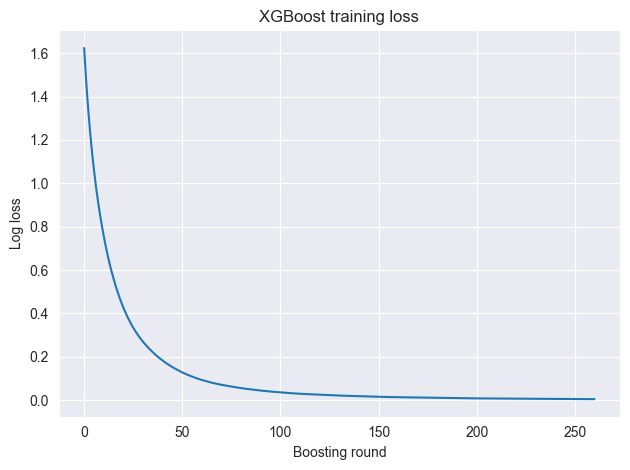

In [95]:
best_xgb = xgb.XGBClassifier(**study_xgb.best_params, tree_method='hist', random_state=42)
best_xgb.fit(
    X_train, y_train_enc,
    eval_set=[(X_train, y_train_enc)],
    verbose=False
)

results = best_xgb.evals_result()
plt.plot(results['validation_0']['mlogloss'])
plt.title('XGBoost training loss')
plt.xlabel('Boosting round')
plt.ylabel('Log loss')
plt.tight_layout()
plt.show()

In [98]:
xgb_f1 = f1_score(y_test_enc, best_xgb.predict(X_test), average='macro')
print(f'XGBoost final F1-macro: {xgb_f1:.4f}')


XGBoost final F1-macro: 0.9546


In [92]:
from sklearn.svm import SVC

best_svm = SVC(**study_svm.best_params)
best_svm.fit(X_train_s, y_train)
svm_f1 = f1_score(y_test, best_svm.predict(X_test_s), average='macro')
print(f'SVM final F1-macro: {svm_f1:.4f}')


SVM final F1-macro: 0.9605


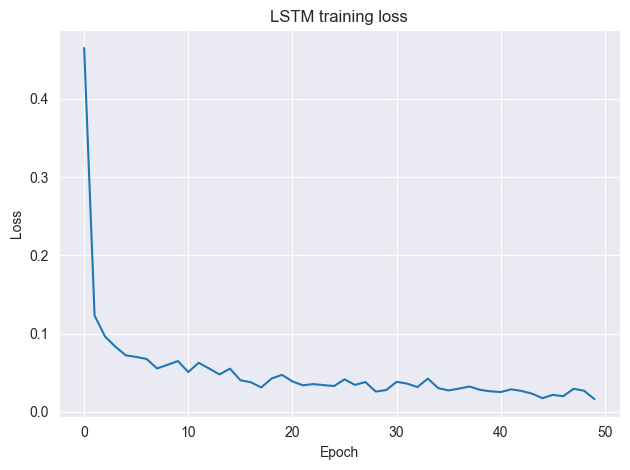

In [99]:
best_lstm_params = study_lstm.best_params

best_lstm_model = LSTMClassifier(
    input_size=X_train_s.shape[1],
    hidden_size=best_lstm_params['hidden_size'],
    num_layers=best_lstm_params['num_layers'],
    dropout=best_lstm_params['dropout'],
    n_classes=len(le.classes_)
).to(DEVICE)

dl = DataLoader(
    TensorDataset(X_train_t.unsqueeze(1), y_train_t),
    batch_size=best_lstm_params['batch_size'],
    shuffle=True
)

opt = torch.optim.Adam(best_lstm_model.parameters(), lr=best_lstm_params['lr'])
criterion = nn.CrossEntropyLoss()

train_losses = []

for epoch in range(50):
    best_lstm_model.train()
    epoch_loss = 0
    for Xb, yb in dl:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = criterion(best_lstm_model(Xb), yb)
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(dl))

plt.plot(train_losses)
plt.title('LSTM training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()


In [100]:
best_lstm_model.eval()
with torch.no_grad():
    lstm_preds = best_lstm_model(X_test_t.unsqueeze(1).to(DEVICE)).argmax(1).cpu().numpy()
lstm_f1 = f1_score(y_test_enc, lstm_preds, average='macro')
print(f'LSTM final F1-macro: {lstm_f1:.4f}')


LSTM final F1-macro: 0.9544


## 6. [R3a/R3b] Results & Analysis

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(colorbar=False, cmap='Blues', xticks_rotation=30)
    plt.title(title)
    plt.tight_layout()
    plt.show()



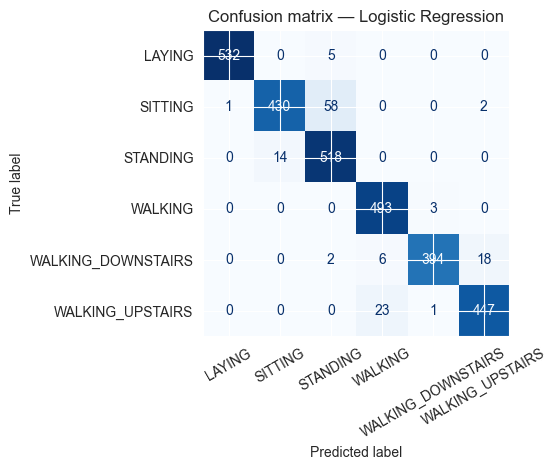

In [103]:
plot_cm(y_test, lr.predict(X_test_s), 'Confusion matrix — Logistic Regression')


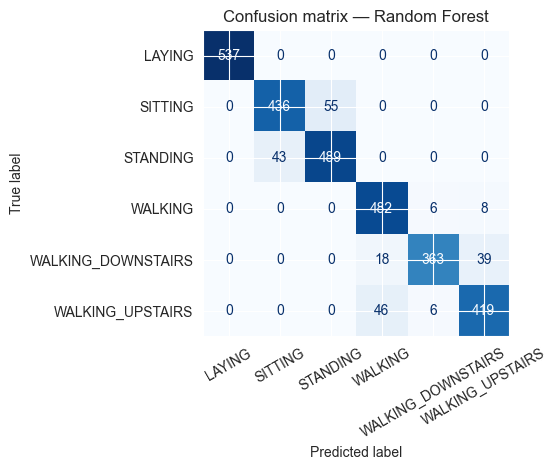

In [104]:
plot_cm(y_test, rf.predict(X_test), 'Confusion matrix — Random Forest')


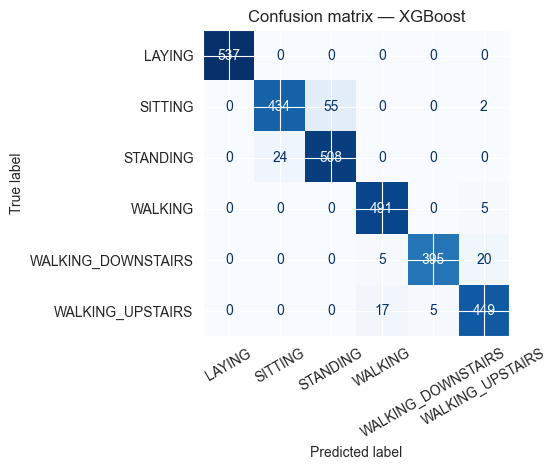

In [105]:
plot_cm(y_test, le.inverse_transform(best_xgb.predict(X_test)), 'Confusion matrix — XGBoost')


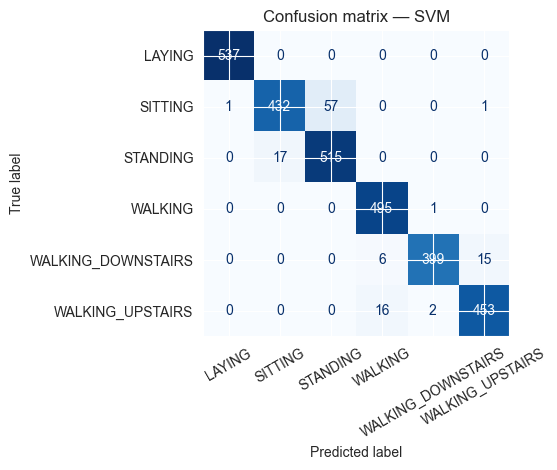

In [106]:
best_svm = SVC(**study_svm.best_params)
best_svm.fit(X_train_s, y_train)
y_pred_svm = best_svm.predict(X_test_s)

plot_cm(y_test, y_pred_svm, 'Confusion matrix — SVM')


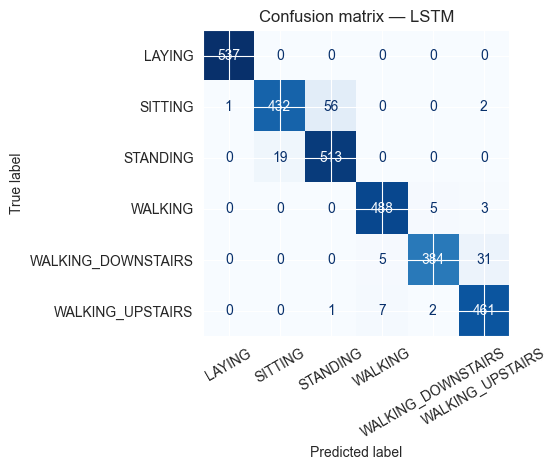

In [102]:
plot_cm(y_test, le.inverse_transform(lstm_preds), 'Confusion matrix — LSTM')


### Results table

In [112]:
results = pd.DataFrame([
    {'Model': 'Naive LSTM baseline', 'F1-macro': 0.800},
    {'Model': 'Random Forest', 'F1-macro': f1_score(y_test, rf.predict(X_test), average='macro')},
    {'Model': 'LSTM (HPO)', 'F1-macro': f1_score(y_test, le.inverse_transform(lstm_preds), average='macro')},
    {'Model': 'Logistic Regression', 'F1-macro': f1_score(y_test, lr.predict(X_test_s), average='macro')},
    {'Model': 'XGBoost (HPO)', 'F1-macro': f1_score(y_test, le.inverse_transform(best_xgb.predict(X_test)), average='macro')},
    {'Model': 'SVM (HPO)', 'F1-macro': f1_score(y_test, y_pred_svm, average='macro')},
]).sort_values('F1-macro')

print(results.to_string(index=False))


              Model  F1-macro
Naive LSTM baseline  0.800000
      Random Forest  0.923431
         LSTM (HPO)  0.954447
      XGBoost (HPO)  0.954569
Logistic Regression  0.954718
          SVM (HPO)  0.960520


### Overlap misclassified on T-SNE

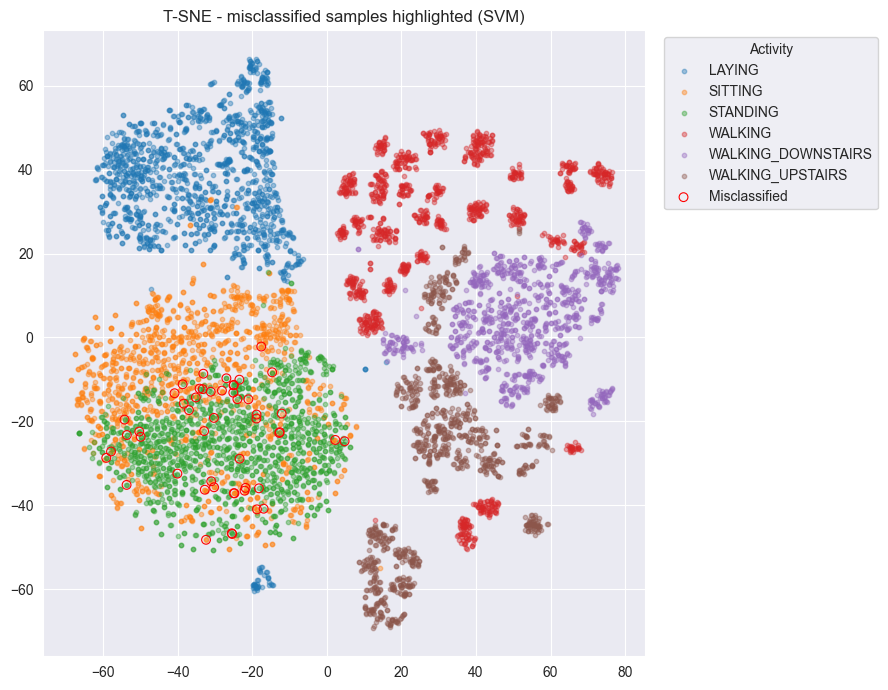

In [108]:
svm_train_preds = best_svm.predict(X_train_s)
misclassified = svm_train_preds != y_train

plt.figure(figsize=(9, 7))
for activity in np.unique(y_train):
    mask = y_train == activity
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=activity, alpha=0.4, s=10)

# Overlay misclassified points
plt.scatter(X_2d[misclassified, 0], X_2d[misclassified, 1],
            facecolors='none', edgecolors='red', s=40, linewidths=0.8, label='Misclassified')

plt.legend(title='Activity', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('T-SNE - misclassified samples highlighted (SVM)')
plt.tight_layout()
plt.show()


Interesting the misclassified items are in the SITTING/STANDING overlap region

### Feature importance (XGBoost)

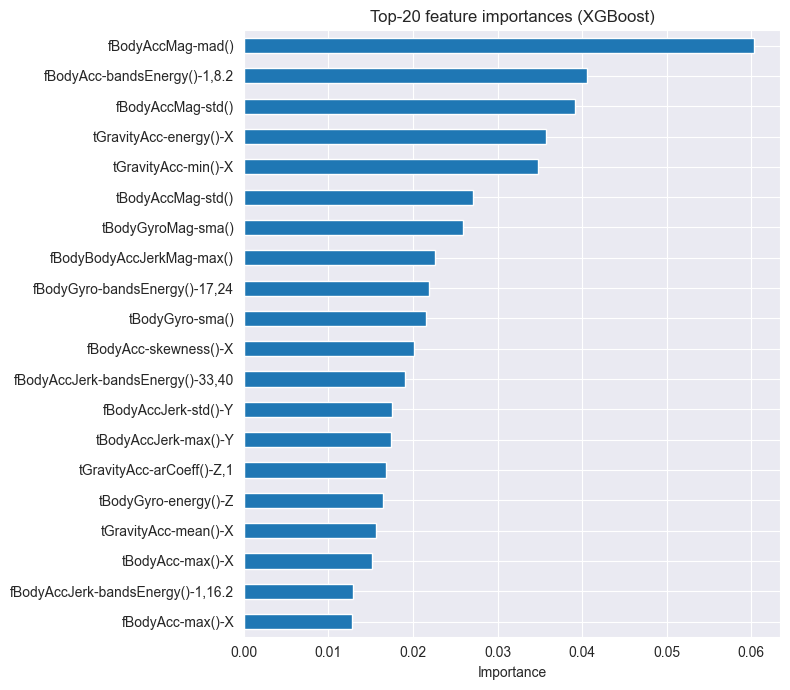

In [86]:
importances = pd.Series(best_xgb.feature_importances_,
                        index=df_train.drop(columns=['Activity', 'subject']).columns)
top20 = importances.nlargest(20).sort_values()

top20.plot(kind='barh', figsize=(8, 7), title='Top-20 feature importances (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
